In [1]:
from importlib import reload

from pathlib import Path
import pandas as pd
import pruner_eval
reload(pruner_eval)
from pruner_eval import load_docs, sentence_wise_metrics, filter_ent_preds, save_docs

In [24]:

date_model = "2025-05-09"
date_data = "2025-05-19"
annotator = "_Suyash"
annotator = ""
#date_data = date_model
run_name = "first_try"
pred_base_path = Path(f"../saves/gsap/pruner/{run_name}")
target_path = Path(f"../saves/gsap/pruned_ner/{date_data}")
target_path.mkdir(parents=True, exist_ok=True)

# Find best parameter

In [25]:
fn_dev = pred_base_path / f"ent_pred_{date_data}{annotator}_dev.json"
docs = load_docs(fn_dev)
len(docs)

10

In [26]:
steps = 20
pred_max = 18
threshold_len_mult = 10.
precision_recall_curve = []
for threshold in range(steps + 1):
    threshold = (threshold/steps) #* 0.5# + 0.0007
    metrics = sentence_wise_metrics(docs, threshold, threshold_len_mult=threshold_len_mult, pred_max=pred_max)
    recall = metrics.tp.sum() / metrics.support.sum()
    precision = 1.
    if metrics.n_predicted.sum():
        precision = metrics.tp.sum() / metrics.n_predicted.sum()
    precision_recall_curve.append(dict(recall=recall, precision=precision, threshold=threshold, n_predicted=metrics.n_predicted.sum()))

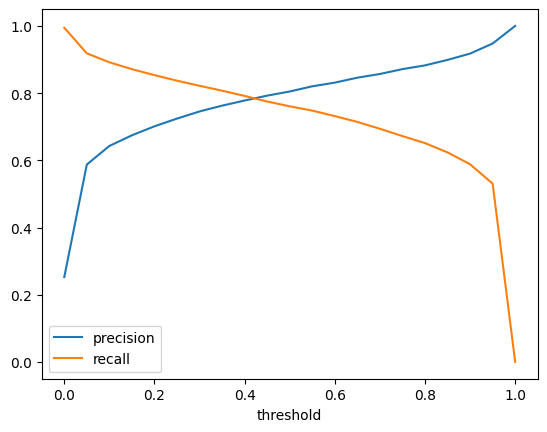

In [27]:
pr_rec = pd.DataFrame(precision_recall_curve)
pr_rec.set_index("threshold")[["precision", "recall"]].plot();

0.0 0.001


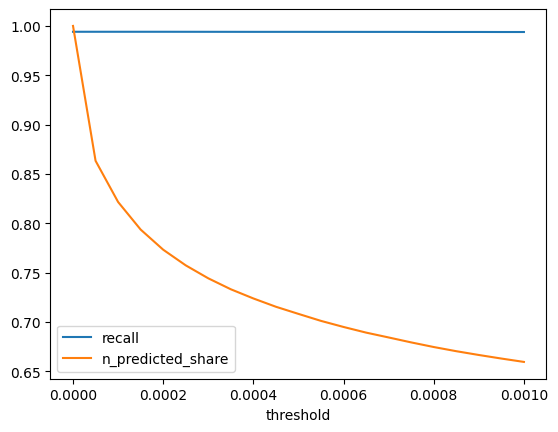

In [37]:
steps = 20
pred_max = 18
threshold_len_mult = 5.
precision_recall_curve = []
min_threshold = None
max_threshold = None
for step in range(steps + 1):
    threshold = (step / steps) * 0.001# + 0.0007
    if step == 0:
        min_threshold = threshold
    max_threshold = threshold
    metrics = sentence_wise_metrics(docs, threshold, threshold_len_mult=threshold_len_mult, pred_max=pred_max)
    recall = metrics.tp.sum() / metrics.support.sum()
    precision = 1.
    if metrics.n_predicted.sum():
        precision = metrics.tp.sum() / metrics.n_predicted.sum()
    precision_recall_curve.append(dict(recall=recall, precision=precision, threshold=threshold, n_predicted=metrics.n_predicted.sum()))
print(min_threshold, max_threshold)
pr_rec = pd.DataFrame(precision_recall_curve)
pr_rec["n_predicted_share"] = pr_rec["n_predicted"] / pr_rec["n_predicted"].max()
pr_rec.set_index("threshold")[["recall", "n_predicted_share"]].plot();

In [38]:
pr_rec[["threshold", "recall", "n_predicted_share", "n_predicted", "precision"]]

,threshold,recall,n_predicted_share,n_predicted,precision
0,0.00000,0.994078,1.000000,181022,0.267967
1,0.00005,0.994078,0.863293,156275,0.310402
2,0.00010,0.994078,0.821536,148716,0.326179
3,0.00015,0.994078,0.793589,143657,0.337665
4,0.00020,0.994078,0.773188,139964,0.346575
5,0.00025,0.994057,0.757317,137091,0.353831
6,0.00030,0.994037,0.744180,134713,0.360069
7,0.00035,0.994016,0.733071,132702,0.365518
8,0.00040,0.993996,0.723779,131020,0.370203
9,0.00045,0.993996,0.715355,129495,0.374563


In [34]:
f = pr_rec.recall <= 0.991
assert f.value_counts().get(True)
threshold = pr_rec[f].iloc[0].threshold
threshold

np.float64(0.0003)

In [35]:
fn_dev

PosixPath('../saves/gsap/pruner/first_try/ent_pred_2025-05-19_dev.json')

# Save the pruned results

In [36]:
fns = [pred_base_path / f"ent_pred_somd_phase1_{split}.json"
       for split in ["train", "dev", "test"]]
fns = [pred_base_path / f"ent_pred_{date_data}{annotator}_{split}.json"
       for split in ["dev", "test", "train"]]
#fns = [fn_dev]
if True:
    for fn in fns:
        name = fn.name
        fn_target = target_path / name
        print(fn_target)
        docs = load_docs(fn)
        print(len(docs))
        filter_ent_preds(docs, threshold, pred_max=18)
        #for doc in docs:
        #    doc["relations"] = [[] for _ in range(len(doc["relations"]))]
        #    doc["ner"] = [[] for _ in range(len(doc["relations"]))]
        save_docs(docs, fn_target)

../saves/gsap/pruned_ner/2025-05-19/ent_pred_2025-05-19_dev.json
10
../saves/gsap/pruned_ner/2025-05-19/ent_pred_2025-05-19_test.json
10
../saves/gsap/pruned_ner/2025-05-19/ent_pred_2025-05-19_train.json
80


In [23]:
docs[0]["ner"]

[[[3, 3, 'Application'], [5, 9, 'AlternativeName']]]

In [24]:
skipped_sents = 0
not_skipped_sents = 0
n_ents = 0
n_ents_pred = 0
n_rels = 0
for doc in docs_gt_test:
    for rels in doc["relations"]:
        n_rels += len(rels)
    for pred in doc["predicted_ner"]:
        n_ents_pred += len(pred)
    for pred in doc["ner"]:
        n_ents += len(pred)
        if pred:
            not_skipped_sents += 1
        else:
            skipped_sents += 1
skipped_sents, not_skipped_sents, n_ents, n_ents_pred, n_rels 

NameError: name 'docs_gt_test' is not defined

In [602]:
46998 / 48274 


0.9735675518912872

## find candidates for annotation!

In [47]:
fn_dev

PosixPath('../saves/somd/pruner/entnum/somd_phase1_scibert_data-bs16-1e-5-4-44/ent_pred_somd_phase2_test.json')

In [26]:
#fn_train, fn_dev, fn_test = fns
docs = load_docs(fn_dev)

In [36]:
limit = 100
sents_with_new_cand = 0
total_candidates = 0
total_delete_candidates = 0
ok = 0
candidates = []
candidate_errors = []
for doc_idx, doc in enumerate(docs):
    doc_idx = doc_idx
    doc_id = doc["doc_id"]
    for sent_idx, preds in enumerate(doc["predicted_ner_proba"]):
        sent_ner = doc["ner"][sent_idx]
        #url_inception = doc["url_inception"][sent_idx]
        sent_ner_spans = {(begin, end) for begin, end, label in sent_ner}
        cands = [(begin, end, proba, _) for begin, end, proba, _ in preds
                 if proba > 0.5 and (begin, end) not in sent_ner_spans]
        #if sent_idx == 0:
        #    import pdb; pdb.set_trace()
        possible_errors = [(begin, end, proba, _) for begin, end, proba, _ in preds
                 if proba <= 1. and (begin, end) in sent_ner_spans]
        total_candidates += len(cands)
        total_delete_candidates += len(possible_errors)
        if cands:
            sents_with_new_cand += 1
        else:
            ok += 1
        sent = " ".join(doc["sentences"][sent_idx])
        #annotator = url_inception[url_inception.rfind("=") + 1:]
        cands = [("candidate", c) for c in cands]
        possible_errors = [("error?", p) for p in possible_errors]
        for candidate_type, (begin, end, proba, _) in cands + possible_errors:
            ent = " ".join(doc["doc_tokens"][begin:end + 1])
            candidates.append(dict(
                candidate_type=candidate_type,
                suggestion = ent,
                sent_idx=sent_idx,
                score=proba,
                doc_id=doc_id,
                doc_idx=doc_idx,
                sent=sent,
            ))
                #annotator=annotator,
                #url_inception=url_inception
cands = pd.DataFrame(candidates)
sents_with_new_cand, ok, total_candidates, total_delete_candidates, len(candidates)

(134, 86, 283, 818, 1101)

In [37]:
cands.doc_id.value_counts()

doc_id
ood_201    24
ood_87     19
ood_90     16
ood_161    16
ood_124    15
           ..
ood_65      2
ood_66      2
ood_186     2
ood_187     2
ood_0       2
Name: count, Length: 220, dtype: int64

In [38]:
f = cands.doc_id == "PMC3281188"
f = cands.doc_id.apply(lambda x: True)
print(len(cands[f]))
cands[f].sort_values("sent_idx", ascending=True)[:40]#.annotator.value_counts()

1101


,candidate_type,suggestion,sent_idx,score,doc_id,doc_idx,sent
0,error?,3DSim,0,0.993162,ood_0,0,Here we present 3DSim ( 3D Structural Implicat...
724,error?,https://scicrunch.org/resolver/RRID:SRC_013291,0,0.417781,ood_143,143,The set of deduplicated reads was used for ChI...
725,error?,epic 2,0,0.045442,ood_143,143,The set of deduplicated reads was used for ChI...
726,error?,epic 2,0,0.005090,ood_143,143,The set of deduplicated reads was used for ChI...
727,candidate,1 . 2,0,0.993422,ood_144,144,Additional steps in the workflow are aimed at ...
728,error?,DeepTools,0,0.999946,ood_144,144,Additional steps in the workflow are aimed at ...
729,error?,Deeptools,0,0.999877,ood_144,144,Additional steps in the workflow are aimed at ...
730,error?,3 . 1 . 2,0,0.999745,ood_144,144,Additional steps in the workflow are aimed at ...
731,error?,MultiQC,0,0.998123,ood_144,144,Additional steps in the workflow are aimed at ...
732,error?,[ 58 ],0,0.994965,ood_144,144,Additional steps in the workflow are aimed at ...


In [195]:
print_doc(1,29)
#doc = docs[doc_idx]

For example , hydrophobicity is an average characteristic of interacting surfaces in homodimers , but has only limited power of predicting interaction sites in some types of complexes .
prediction
	[NIL: 'hydrophobicity' (0.34)
	[NIL: 'homodimers' (0.00)
	[NIL: 'interacting surfaces' (0.00)
	[NIL: 'example' (0.00)
	[NIL: 'average' (0.00)
	[NIL: 'interaction sites' (0.00)
	[NIL: 'complexes' (0.00)
	[NIL: 'some' (0.00)
	[NIL: 'limited power' (0.00)
	[NIL: 'but' (0.00)
relations


In [48]:
from itertools import chain

In [49]:
def print_doc(doc_idx, sent_idx=0):
    doc = docs[doc_idx]
    doc_token = list(chain(*doc["sentences"]))
    sent = doc["sentences"][sent_idx]
    print(" ".join(sent))
    
    for begin, end, label in doc["ner"][sent_idx]:
        text = " ".join(doc_token[begin:end+1])
        print(label, text)
    
    print("prediction")
    for begin, end, prob, label in doc["predicted_ner_proba"][sent_idx]:
        text = " ".join(doc_token[begin:end+1])
        print(f"\t[{label}: '{text}' ({prob:0.2f})")
    
    print("relations")
    for subj_begin, subj_end, obj_begin, obj_end, label in doc["relations"][sent_idx]:
        subj_text = " ".join(doc_token[subj_begin: subj_end+1])
        obj_text = " ".join(doc_token[obj_begin: obj_end+1])
        print(f"\t{subj_text} - ({label}) -> {obj_text}")
    

In [50]:
f = cands.annotator=="Suyash"
cands[f].sort_values("score", ascending=False).head(50).to_dict(orient="records")

AttributeError: 'DataFrame' object has no attribute 'annotator'

In [449]:
#fn = "delete.json"
#save_docs(docs, fn)

In [450]:
docs = load_docs(fn)
len(docs)

10

In [532]:
skipped_sents = 0
not_skipped_sents = 0
for doc in docs:
    for pred in doc["predicted_ner"]:
        if pred:
            not_skipped_sents += 1
        else:
            skipped_sents += 1
skipped_sents, not_skipped_sents

(0, 2958)

# Find a good threshold

In [63]:
from importlib import reload
import pandas as pd
from pathlib import Path

import pruner_eval
reload(pruner_eval)
from pruner_eval import load_docs, sentence_wise_metrics, filter_ent_preds, save_docs

In [ ]:
fn_dev = "../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs16-entnum30-30-lr1e-5-epochs5/gsap_scibert_new_data_not_null-bs16-44/ent_pred_dev.json"
fn_dev = "../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs8-entnum30-30-lr1e-5-epochs2/gsap_scibert_data2025-02-08-bs16-1e-5-44/ent_pred_2025-02-08_dev.json"
fn_dev = "../saves/gsap/pruner/entnum30-30-lr1e-5-epochs4/gsap_scibert_data_2025-03-06-bs16-1e-5-4-44/ent_pred_2025-03-06_dev.json"
docs = load_docs(fn_dev)
len(docs)

10

In [81]:
steps = 20
pred_max = 18
threshold_len_mult = 5.
precision_recall_curve = []
for threshold in range(steps + 1):
    threshold = (threshold/steps) * 0.001# + 0.0007
    metrics = sentence_wise_metrics(docs, threshold, threshold_len_mult=threshold_len_mult, pred_max=pred_max)
    recall = metrics.tp.sum() / metrics.support.sum()
    precision = 1.
    if metrics.n_predicted.sum():
        precision = metrics.tp.sum() / metrics.n_predicted.sum()
    precision_recall_curve.append(dict(recall=recall, precision=precision, threshold=threshold, n_predicted=metrics.n_predicted.sum()))

In [82]:
## estimate len_mult threshhold

In [84]:
a = pd.DataFrame(precision_recall_curve)
a#[:10]
#a.plot(kind="line", x="precision", y="recall")

,recall,precision,threshold,n_predicted
0,0.994136,0.272239,0.00000,21797
1,0.993969,0.307059,0.00005,19322
2,0.993801,0.320285,0.00010,18521
3,0.993466,0.329298,0.00015,18008
4,0.993299,0.336798,0.00020,17604
5,0.993299,0.342935,0.00025,17289
6,0.992964,0.348299,0.00030,17017
7,0.992629,0.352973,0.00035,16786
8,0.992461,0.356910,0.00040,16598
9,0.992294,0.360105,0.00045,16448


In [51]:
threshold_len_mult = (0, 10)
precision_recall_curve = []
mini, maxi = threshold_len_mult
for threshold in range(mini * 10, maxi * 10):
    threshold = threshold 
    print(threshold)
    metrics = sentence_wise_metrics(docs, 0.00015, threshold_len_mult=threshold, pred_max=18, mini=1)
    recall = metrics.tp.sum() / metrics.support.sum()
    precision = 1.
    if metrics.n_pred.sum():
        precision = metrics.tp.sum() / metrics.n_pred.sum()
    precision_recall_curve.append(dict(recall=recall, precision=precision, threshold=threshold))

0
x 18
[[13, 15, 0.9396957159042358, 'MLModelGeneric'], [14, 15, 0.5020531415939331, 'NIL'], [27, 27, 0.10915670543909073, 'NIL'], [12, 12, 0.0203004889190197, 'NIL'], [25, 25, 0.0014015424530953169, 'NIL'], [2, 2, 0.0009454019018448889, 'NIL'], [7, 10, 0.0006747008883394301, 'NIL'], [13, 13, 8.45792455947958e-05, 'NIL']]

y 0
1
z 1
[[13, 15, 0.9396957159042358, 'MLModelGeneric']]

{(13, 15)}


Exception: 

In [639]:
#10 / 33.3

In [393]:
int(0.3)

0

## Estimate threshold probability

In [26]:
docs[0].keys()
docs[0]["predicted_ner_proba"]

[[[13, 15, 0.9396957159042358, 'MLModelGeneric'],
  [14, 15, 0.5020531415939331, 'NIL'],
  [27, 27, 0.10915670543909073, 'NIL'],
  [12, 12, 0.0203004889190197, 'NIL'],
  [25, 25, 0.0014015424530953169, 'NIL'],
  [2, 2, 0.0009454019018448889, 'NIL'],
  [7, 10, 0.0006747008883394301, 'NIL'],
  [13, 13, 8.45792455947958e-05, 'NIL']],
 [[43, 45, 0.09251399338245392, 'NIL'],
  [53, 55, 0.06960085779428482, 'NIL'],
  [41, 41, 0.041155703365802765, 'NIL'],
  [59, 62, 0.033898718655109406, 'NIL'],
  [47, 47, 0.03373359143733978, 'NIL'],
  [67, 68, 0.029491499066352844, 'NIL'],
  [37, 38, 0.02161300927400589, 'NIL'],
  [64, 64, 0.012766451574862003, 'NIL'],
  [30, 31, 0.009044022299349308, 'NIL']],
 [[100, 101, 0.9935503005981445, 'MLModelGeneric'],
  [81, 85, 0.8777391314506531, 'NIL'],
  [82, 85, 0.18978610634803772, 'Method'],
  [76, 77, 0.07137425988912582, 'NIL'],
  [100, 100, 0.06709311902523041, 'NIL'],
  [75, 75, 0.025358479470014572, 'NIL'],
  [99, 99, 0.023262614384293556, 'NIL'],
  [

0.0


ZeroDivisionError: float division by zero

In [646]:
a = pd.DataFrame(precision_recall_curve)
#a.plot(kind="line", x="precision", y="recall")
a

,recall,precision,threshold
0,0.994611,0.251775,0.00000
1,0.993818,0.283531,0.00005
2,0.993660,0.295554,0.00010
3,0.993501,0.305072,0.00015
4,0.993026,0.311521,0.00020
5,0.992709,0.317806,0.00025
6,0.992392,0.322865,0.00030
7,0.992233,0.327629,0.00035
8,0.992233,0.331427,0.00040
9,0.991916,0.334957,0.00045


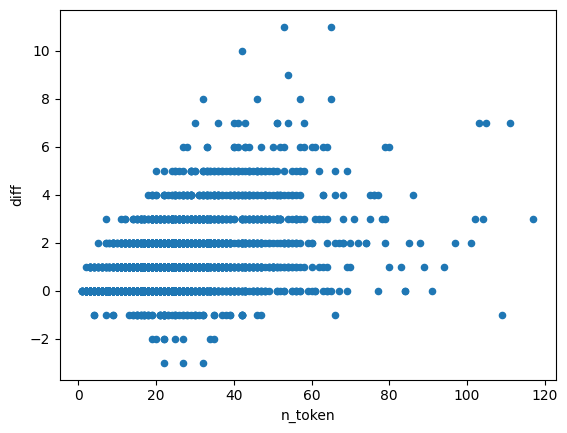

In [547]:
docs = load_docs(fn_train)
metrics = sentence_wise_metrics(docs, 0.05, threshold_len_mult=None, pred_max=18)
metrics.plot(kind="scatter", x="n_token", y="diff");

In [276]:
# precision recall curve

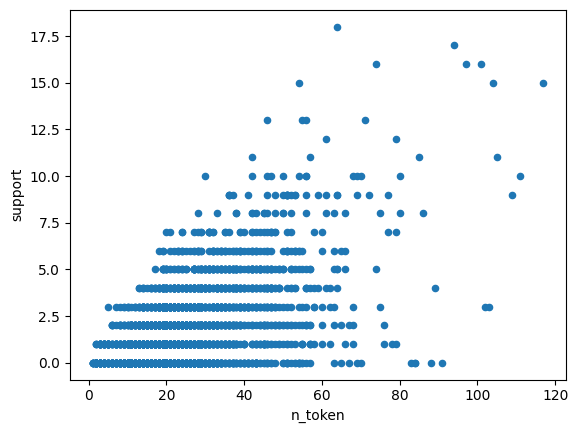

In [311]:
metrics.plot(kind="scatter", x="n_token", y="support");

In [ ]:
metrics

,recall,n_token,n_pred_max,tp,fn,fp,sent_id
0,1.0,30,8,1,0,2,"(00015_1910_09700.txt, 0)"
1,1.0,42,8,0,0,6,"(00015_1910_09700.txt, 1)"
2,1.0,31,10,2,0,3,"(00015_1910_09700.txt, 2)"
3,1.0,31,6,0,0,1,"(00015_1910_09700.txt, 3)"
4,1.0,5,3,0,0,1,"(00015_1910_09700.txt, 4)"
...,...,...,...,...,...,...,...
2952,1.0,23,8,2,0,3,"(10052_2106_02584.txt, 760)"
2953,0.7,80,22,7,3,1,"(10052_2106_02584.txt, 761)"
2954,1.0,25,6,1,0,3,"(10052_2106_02584.txt, 762)"
2955,1.0,33,10,4,0,1,"(10052_2106_02584.txt, 763)"


In [219]:
import json
import random
from itertools import chain

NameError: name 'pd' is not defined

In [206]:
#sent_begin = 0
#for doc in docs:
#    for sent_idx, sentence in enumerate(doc["sentences"]):
#        sent_ner_preds = doc["predicted_ner_proba"][sent_idx]
#        for begin, end, label, proba in sent_ner_preds:
#            if begin >= sent_begin + len(sentence):
#                print("ihh")
#        sent_begin += len(sentence)

In [207]:
import pandas as pd

In [209]:
stats = get_results(docs)

<AxesSubplot:xlabel='n_token', ylabel='n_pred_max'>

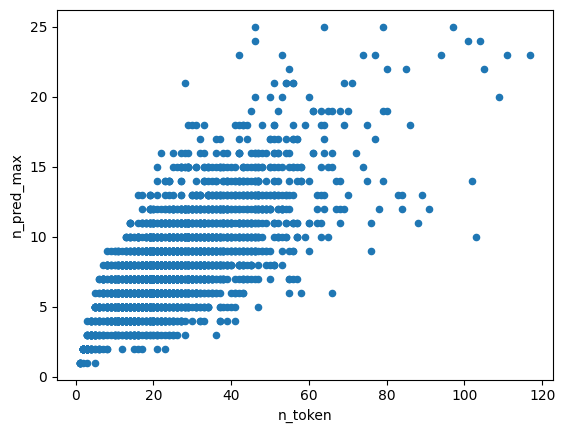

In [163]:
get_results(docs).n_token.describe()

count    2957.000000
mean       25.981062
std        14.406586
min         1.000000
25%        16.000000
50%        23.000000
75%        33.000000
max       117.000000
Name: n_token, dtype: float64

In [ ]:
recall_1_share = (sent_recall.recall == 1.).value_counts().get(True) / len(sent_recall)
recall_all = sent_recall.tp.sum() / (sent_recall.tp.sum() + sent_recall.fn.sum())
precision_all = sent_recall.tp.sum() / (sent_recall.tp.sum() + sent_recall.fp.sum())
predicted_ents = (sent_recall.fp.sum() / sent_recall.tp.sum()  )
recall_all, precision_all, recall_1_share, predicted_ents, sent_recall.fp.sum(), sent_recall.tp.sum()

(0.9256553502363558,
 0.6571079926784624,
 0.6915032679738562,
 0.5218198700092851,
 1124,
 2154)

In [117]:
import numpy as np

In [125]:
bad_recall = sent_recall.recall < 0.5
sent_recall.loc[bad_recall[bad_recall].index]

,sent_idx,recall,tp,fn,fp
65,65,0.333333,1,2,4
86,86,0.000000,0,2,0
221,221,0.000000,0,1,2
228,228,0.000000,0,1,2
249,249,0.428571,3,4,4
314,314,0.000000,0,1,0
391,391,0.000000,0,1,0
406,406,0.333333,1,2,3
412,412,0.000000,0,1,2
415,415,0.000000,0,1,2


In [100]:
sent_infos_fn = [i for i in sent_infos if i["recall"] is not None and i["recall"] <= 1.]
len(sent_infos_fn)

649

In [101]:
tp = len(ner_set & ner_pred_set)
fn = len(ner_set - ner_pred_set)
fp = len(ner_pred_set - ner_set)
recall = tp / len(ner_set)
recall, tp, fn, fp


(1.0, 3, 0, 3)

In [ ]:
sent_info = random.choice(sent_infos_fn)

In [126]:
idx = -1

In [134]:
idx += 1
pos = bad_recall[bad_recall].index[idx]
print(pos)
sent_info = sent_infos_fn[pos]

print(sent_info)
sent_idx = sent_info["sent_idx"]
sentence = doc["sentences"][sent_idx]
ner_pred = doc["predicted_ner_proba"][sent_idx]
ner = doc["ner"][sent_idx]

print(" ".join(sentence))
print("\nner:")
for begin, end, label in ner:
    print(f'[{label}: "{" ".join(doc["doc_tokens"][begin:end+1])}"]')
print("\npredicted ner candidates:")
for begin, end, prob, label in ner_pred:
    print(f'[{label}: "{" ".join(doc["doc_tokens"][begin:end+1])}" ({prob:.2f})]')

249
{'sent_idx': 277, 'recall': 1.0, 'tp': 5, 'fn': 0, 'fp': 5}
NPTs share scaling limitations with all naïvely non - parametric approaches [ 74 ] and GNNs [ 52 ] .

ner:
[ModelArchitecture: "NPTs"]
[MLModelGeneric: "NPTs"]
[MLModelGeneric: "all naïvely non - parametric approaches"]
[ReferenceLink: "74"]
[ModelArchitecture: "GNNs"]
[ReferenceLink: "52"]

predicted ner candidates:
[ReferenceLink: "74" (1.00)]
[ReferenceLink: "52" (1.00)]
[ModelArchitecture: "NPTs" (0.99)]
[ModelArchitecture: "GNNs" (0.99)]
[MLModelGeneric: "all naïvely non - parametric approaches" (0.65)]
[NIL: "naïvely non - parametric approaches" (0.08)]
[NIL: "scaling" (0.04)]
[NIL: "all" (0.01)]
[NIL: "74 ]" (0.00)]
[NIL: "52 ]" (0.00)]


In [57]:
for begin, end, label in ner_pred:
    print(doc["doc_tokens"][begin:end+1], label)

['Instances'] NIL
['few', 'features'] NIL
['learning'] NIL
['accurate', 'feature', 'predictors'] NIL
['feature', 'predictors'] MLModelGeneric
